### Notebook to play with model ,then input funcotuon in machine learning version.py


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from image_processing import read_img,show_img
from machine_learning_version import extract_features,extract_label
from sklearn.metrics import root_mean_squared_error 
from simple_statistics import create_confusions_matrix
import os
import numpy as np

INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"

KERNEL_SIZE:int=5
BOUNDARY:int=300

In [2]:
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]

data=list(zip(input_images,manual_images,mask_images))
print(data)
print(len(data))

[('./images/01_dr.JPG', './manual1/01_dr.tif', './mask/01_dr_mask.tif'), ('./images/01_g.jpg', './manual1/01_g.tif', './mask/01_g_mask.tif'), ('./images/01_h.jpg', './manual1/01_h.tif', './mask/01_h_mask.tif'), ('./images/02_dr.JPG', './manual1/02_dr.tif', './mask/02_dr_mask.tif'), ('./images/02_g.jpg', './manual1/02_g.tif', './mask/02_g_mask.tif'), ('./images/02_h.jpg', './manual1/02_h.tif', './mask/02_h_mask.tif'), ('./images/03_dr.JPG', './manual1/03_dr.tif', './mask/03_dr_mask.tif'), ('./images/03_g.jpg', './manual1/03_g.tif', './mask/03_g_mask.tif'), ('./images/03_h.jpg', './manual1/03_h.tif', './mask/03_h_mask.tif'), ('./images/04_dr.JPG', './manual1/04_dr.tif', './mask/04_dr_mask.tif'), ('./images/04_g.jpg', './manual1/04_g.tif', './mask/04_g_mask.tif'), ('./images/04_h.jpg', './manual1/04_h.tif', './mask/04_h_mask.tif'), ('./images/05_dr.JPG', './manual1/05_dr.tif', './mask/05_dr_mask.tif'), ('./images/05_g.jpg', './manual1/05_g.tif', './mask/05_g_mask.tif'), ('./images/05_h.jp

In [3]:
all_features=[]
all_lebels=[]
for idx,element in enumerate(data):
    img=read_img(element[0])
    manual_=read_img(element[1])
    mask_=read_img(element[2])

    manual_=manual_[:,:,1]
    manual_=np.where(manual_>0,1,0)
    max_x,max_y,_=img.shape
    center_x,center_y=max_x//2,max_y//2

    half = KERNEL_SIZE // 2
    
    for x in range(center_x-BOUNDARY, center_x+BOUNDARY):

        for y in range(center_y-BOUNDARY, center_y+BOUNDARY):

            patch = img[x-half:x+half+1,y-half:y+half+1]

            label_patch = manual_[x-half:x+half+1,y-half:y+half+1]

            features_sample = extract_features(patch)

            all_features.append(features_sample)

            all_lebels.append(
                extract_label(label_patch, KERNEL_SIZE)
            )
            if len(all_features)>(idx+1)*100_000:
                break
        if idx>10:
            break

    #for x in range(KERNEL_SIZE//2+600,max_x-KERNEL_SIZE//2):
        #for y in range(KERNEL_SIZE//2+800,max_y-KERNEL_SIZE//2):

In [4]:
print(len([x for x in all_lebels if x==0]))
print(len([x for x in all_lebels if x==1]))
    

1048983
71852


In [5]:
X_train, X_test, y_train, y_test = train_test_split(all_features, all_lebels, test_size=0.30, random_state=42)

random_under_sampler=RandomUnderSampler(sampling_strategy=1.0,random_state=42)
X_train,y_train=random_under_sampler.fit_resample(X_train,y_train)
print(y_train.count(1))
print(y_train.count(0))


50380
50380


In [6]:
clasifier=RandomForestClassifier().fit(X_train,y_train)

In [40]:
predictions=[]
for idx,(x, y ) in enumerate(zip(X_test, y_test)):
    pred=clasifier.predict(np.array(x).reshape(1, -1))
    #val=root_mean_squared_error(np.array([y]),pred)
    predictions.append(pred[0])
    if idx==9_999:
        break

0.5489080068645383


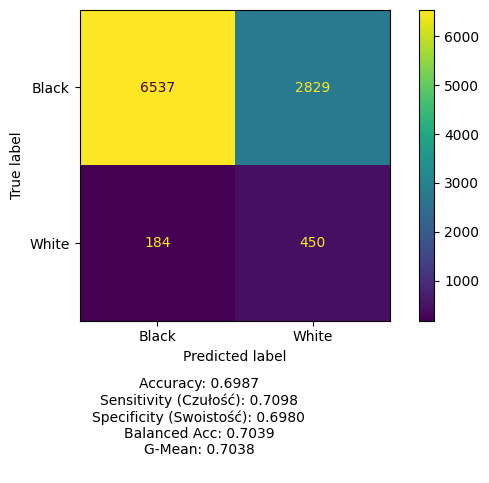

In [41]:
from simple_statistics import create_confusions_matrix
print(root_mean_squared_error(y_test[:10000],predictions))
create_confusions_matrix(np.array(y_test[:10000]),np.array(predictions))

# Dodac przeszulowanie do znalezeniea najlepszego parametru